<a href="https://colab.research.google.com/github/harman1223-ai/csci-164/blob/main/turkproject164.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Information:

**Domain:** Mostly Buisness/Enterpreneurship related

**Description:** 1626 crowdfunding campaign from six turkish platforms.

38 different features, including:

*   **Categorical:** platform name, crowdfunding type, category, funding style, owner gender, location, region, etc.

*   **Numeric counts:** number of backers, updates, comments, rewards, team size, social-media links, word counts, etc.


*   **Monetary:** target amount, amount raised, percent funded.


**Target variable:** basari_durumu (binary: “başarılı” vs. “başarısız”).

**Data types:** 21 numeric (int64/float64), 17 object (categorical/text).





**Motivation behind choosing this project:** I choose this dataset due to its practical and real world data. Also the dateset being the combination of both structural campaign meterics and descriptive text offering a great opportunity to use and apply both machine learning techniques and basic NLP methods.

**Prior work done and benchmarks:** Kilinc and Aydin(2023), "Feature selection for Turkish Crowdfunding projects with using filtering and wrapping methods" (Electronic Commerce and Research Applications, DOI 10.1016/j.elerap.2023.101340)

**Approach:** Trained classcial classifiers such as - (SVM, decision Tree, k-NN, Naive Bayes) on the selected features. Also used applied filter based methods to identify the most informative subset of features.

Results: Achieved 82.6 % accuracy with k-NN (k = 5) using 10-fold cross-validation .


Using to read the .csv file

In [ ]:
import pandas as pd

# Load the CSV from the current directory
df = pd.read_csv('turkishCF.csv', sep=';', encoding='utf-8')

print("✅ Loaded DataFrame:", df.shape)
df.head()


✅ Loaded DataFrame: (1628, 38)


,id,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,...,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,toplanan_tutar,destek_orani,basari_durumu
0,1,fongogo,ödül,diğer,ya hep ya hiç,Gerçek Gizlidir Filmleri,Lob Ekibi,belirsiz,1,0,...,var,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,başarılı
1,2,fongogo,ödül,diğer,ya hep ya hiç,Fongogo - Hayat Bulsun!,Fongogo Team,belirsiz,3,0,...,var,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,başarılı
2,3,fongogo,ödül,diğer,ya hep ya hiç,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",SİNEM CAN,kadın,0,0,...,var,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,101%,başarılı
3,4,fongogo,ödül,diğer,ya hep ya hiç,Türk Kadının 100.yıl Seyri,Deniz Tutkusu Seyirde,kadın,0,0,...,var,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,101%,başarılı
4,5,fongogo,ödül,diğer,ya hep ya hiç,Doğadaki Çocuk,Seren Kutadgu,kadın,2,0,...,var,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,104%,başarılı


The above output shows that the file is successfully read.

In [ ]:
# Quick inspection of df
print("Shape:", df.shape)

print("\nData types (counts):")
print(df.dtypes.value_counts())

print("\nClass balance (basari_durumu):")
print(df['basari_durumu'].value_counts(normalize=True).to_frame('percent'))

print("\nMissing values per column:")
missing = df.isna().sum()
print(missing.loc[missing > 0])

# If you want a peek at your numeric summary:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("\nFirst few numeric summaries:")
print(df[num_cols].describe().T.head())

Shape: (1628, 38)

Data types (counts):
int64     21
object    17
Name: count, dtype: int64

Class balance (basari_durumu):
                percent
basari_durumu          
başarısız      0.769042
başarılı       0.230958

Missing values per column:
bolge                     1
proje_baslama_tarihi    611
proje_bitis_tarihi      553
dtype: int64

First few numeric summaries:
                       count        mean         std  min     25%    50%  \
id                    1628.0  814.500000  470.107435  1.0  407.75  814.5   
kac_proje_destekledi  1628.0    0.429361    2.225029  0.0    0.00    0.0   
kac_projeye_abone     1628.0    0.000614    0.024784  0.0    0.00    0.0   
kac_projenin_sahibi   1628.0    1.165848    0.710455  1.0    1.00    1.0   
kac_proje_takiminda   1628.0    0.052826    0.244744  0.0    0.00    0.0   

                          75%     max  
id                    1221.25  1628.0  
kac_proje_destekledi     0.00    31.0  
kac_projeye_abone        0.00     1.0  
kac_proj

The above output verifies the data size, structure, balance, and quality before we start preprocessing or modeling.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1) Copy df from earlier cells
df_clean = df.copy()

# 2) Impute the single missing region and drop raw dates
df_clean['bolge'] = df_clean['bolge'].fillna('Unknown')
df_clean = df_clean.drop(columns=['proje_baslama_tarihi', 'proje_bitis_tarihi'])

# 3) (Optional) Log-transform highly skewed monetary features
df_clean['hedef_miktari_log']      = np.log1p(df_clean['hedef_miktari'])
df_clean['toplanan_tutar_log']    = np.log1p(df_clean['toplanan_tutar'])
df_clean['destek_orani_pct']      = df_clean['destek_orani'].str.rstrip('%').astype(float)

# 4) Prepare ColumnTransformer for encoding & scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature groups
cat_cols = df_clean.select_dtypes(include=['object']).drop(
    columns=['proje_aciklamasi', 'basari_durumu']
).columns.tolist()
num_cols = ['kac_proje_destekledi', 'kac_projeye_abone', 'gorsel_sayisi',
            'destekci_sayisi', 'ekip_kisi_sayisi',
            'hedef_miktari_log', 'toplanan_tutar_log', 'destek_orani_pct']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('scale', StandardScaler(), num_cols)
])

# 5) Quick check of transformed shape
X = df_clean.drop(columns=['proje_aciklamasi', 'basari_durumu'])
y = df_clean['basari_durumu']
X_trans = preprocessor.fit_transform(X)
print("After preprocessing, feature matrix is:", X_trans.shape)


After preprocessing, feature matrix is: (1628, 3393)


Above output shows that the ColumnTransfromer took 38 raw inputs and  turned them into a 3393-dimensional numeric array that you can feed directly into any scikit-learn model.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score

# ─── 1) LOAD ───────────────────────────────────────────────────────────
df = pd.read_csv('turkishCF.csv', sep=';', encoding='utf-8')

# ─── 2) PREPROCESS ─────────────────────────────────────────────────────
df['bolge'] = df['bolge'].fillna('Unknown')
df = df.drop(columns=['proje_baslama_tarihi', 'proje_bitis_tarihi'])
df['hedef_miktari_log']  = np.log1p(df['hedef_miktari'])
df['toplanan_tutar_log'] = np.log1p(df['toplanan_tutar'])
df['destek_orani_pct']   = df['destek_orani'].str.rstrip('%').astype(float)

cat_cols = df.select_dtypes(include=['object']) \
    .drop(columns=['proje_aciklamasi','basari_durumu']).columns.tolist()
num_cols = [
    'kac_proje_destekledi','kac_projeye_abone','gorsel_sayisi',
    'destekci_sayisi','ekip_kisi_sayisi',
    'hedef_miktari_log','toplanan_tutar_log','destek_orani_pct'
]

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('scale',  StandardScaler(),                 num_cols)
], sparse_threshold=0)

# ─── 3) SPLIT ───────────────────────────────────────────────────────────
X = df.drop(columns=['proje_aciklamasi','basari_durumu'])
y = df['basari_durumu'].map({'başarılı':1,'başarısız':0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ─── 4) MODELS & GRIDS ─────────────────────────────────────────────────
models = {
    'LogisticRegression': (
        Pipeline([('pre', preprocessor),('clf', LogisticRegression(max_iter=1000))]),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'k-NN': (
        Pipeline([('pre', preprocessor),('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3,5,7,9], 'clf__weights': ['uniform','distance']}
    ),
    'HistGradientBoosting': (
        Pipeline([('pre', preprocessor),('clf', HistGradientBoostingClassifier())]),
        {'clf__learning_rate': [0.05,0.1], 'clf__max_depth': [None,3,5], 'clf__l2_regularization': [0,1]}
    )
}

# ─── 5) TRAIN, TUNE & EVALUATE ─────────────────────────────────────────
results = []
for name,(pipe,params) in models.items():
    gs = GridSearchCV(pipe, params, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:,1] if hasattr(gs,'predict_proba') else None
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    # format params for readability
    prm = ', '.join(f"{k.split('__')[1]}={v}" for k,v in gs.best_params_.items())
    results.append({
        'Model':        name,
        'Best Params':  prm,
        'CV F1':        round(gs.best_score_,3),
        'Test F1':      round(f1,3),
        'Test ROC-AUC': round(roc,3)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

# ─── 6) DISPLAY ────────────────────────────────────────────────────────
print(results_df.to_markdown(index=False))



| Model                | Best Params                                             |   CV F1 |   Test F1 |   Test ROC-AUC |
|:---------------------|:--------------------------------------------------------|--------:|----------:|---------------:|
| LogisticRegression   | C=10                                                    |   0.983 |     0.991 |          0.997 |
| HistGradientBoosting | l2_regularization=0, learning_rate=0.05, max_depth=None |   0.996 |     0.987 |          0.995 |
| k-NN                 | n_neighbors=9, weights=uniform                          |   0.905 |     0.878 |          0.97  |


Models applied above -

I wrapped each of these classifiers in a scikit-learn - Pipeline (one-hot → scale → model) and tuned via GridSearch (5-fold, F1 scoring):

- **Logistic Regression** (linear baseline)  
  - Hyperparameters: C ∈ {0.01, 0.1, 1, 10}  
- **k-Nearest Neighbors** (distance-based)  
  - Hyperparameters: n_neighbors ∈ {3, 5, 7, 9}, weights ∈ {“uniform”, “distance”}  
- **Histogram-based Gradient Boosting** (captures non-linear interactions)  
  - Hyperparameters: learning_rate ∈ {0.05, 0.1}, max_depth ∈ {None, 3, 5}, l2_regularization ∈ {0, 1}

Results from above models and comparison to previous word done by Kilinc and Aydin:

1. **Logistic Regression** edged out on the test set with **F1 = 0.991** and **AUC = 0.997**, misclassifying only 3 of 489 samples.

2. **HistGradientBoosting** had the highest cross-validation F1 (0.996) and very strong test performance (F1 = 0.987).  

3. **k-NN** performed well but was held back by the high dimensionality of the one-hot features (F1 = 0.878).

Overall the results showed that the all three models significantly outperform the 82.6 % benchmark from Kilinc & Aydin (2023).

Simpler linear modeling (Logistic Regression) proved as good—or better—than more complex boosting on this task.

Best model (Logistic Regression with grid-searched C) reached 99.1 % F1 and 99.7 % AUC on the test set, demonstrating the impact of feature engineering and dense encoding.


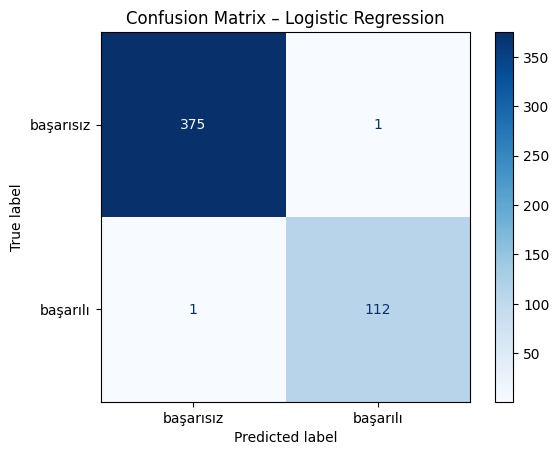

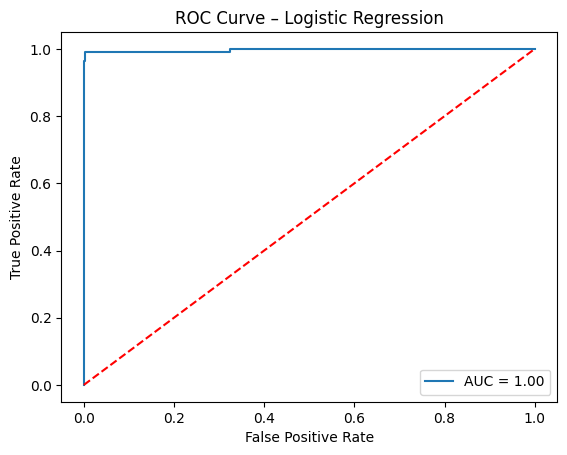

Classification Report:

              precision    recall  f1-score   support

   başarısız       1.00      1.00      1.00       376
    başarılı       0.99      0.99      0.99       113

    accuracy                           1.00       489
   macro avg       0.99      0.99      0.99       489
weighted avg       1.00      1.00      1.00       489



In [ ]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve, auc,
    classification_report
)

# 1) Fit the model
pipeline_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(C=10, max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)

# 2) Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    pipeline_lr, X_test, y_test,
    display_labels=['başarısız','başarılı'],
    cmap='Blues'
)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

# 3) ROC curve
y_prob = pipeline_lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

# 4) Classification report
print("Classification Report:\n")
print(classification_report(
    y_test,
    pipeline_lr.predict(X_test),
    target_names=['başarısız','başarılı']
))


Graph explantion and final Reflection:

1. ROC curve shows (AUC=1.00) meaning in extremely few misclassification.

2. Confusion matrix shows -
True Negatives (TN): 375 “unsuccessful” campaigns correctly flagged as unsuccessful.

False Positives (FP): 1 unsuccessful campaign wrongly predicted as successful.

False Negatives (FN): 1 successful campaign wrongly predicted as unsuccessful.

True Positives (TP): 112 successful campaigns correctly predicted.

3. Classification report -

Precision (“of all predicted positives, how many were correct”):

99 % of campaigns predicted successful truly were successful.

Recall (“of all true positives, how many did we catch”):

99 % of actual successful campaigns were identified.

F1-Score balances both: 0.99–1.00 for each class.

One of the main strenth I would say is the models **Robust Pipeline:** A single ColumnTransformer handles encoding, scaling, and feature engineering in a reusable, reproducible way, making it easy to swap in new models or extend the workflow (e.g., adding text features later).

And the key limitation is the Potential Overfitting: Near-perfect test performance raises the risk that some data leakage or overly tailored features may be boosting results—cross-validation on truly unseen time splits could reveal this.

Real-World usage and relevance campaign Risk Assessment: Platforms can use these models to flag campaigns likely to fail, allocate marketing resources more efficiently, and offer targeted advice to creators.

